# Plot model fit

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from devreact import figures
from devreact import model

model_name = 'neural-dual-v6'

signal_names = ['vlpfc', 'prec', 'ang', 'lpc', 'hpc', 'phc']
roi_names = ['VLPFC', 'Precuneus', 'Angular gyrus', 'IPS/SPL', 'Hippocampus', 'PHC']

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name
fig_dir.mkdir(parents=True, exist_ok=True)

%matplotlib inline
figures.set_style()

In [2]:
pp = az.from_netcdf(fig_dir / 'posterior_predictive.nc')
max_time = 8

## Examine posterior predictive samples

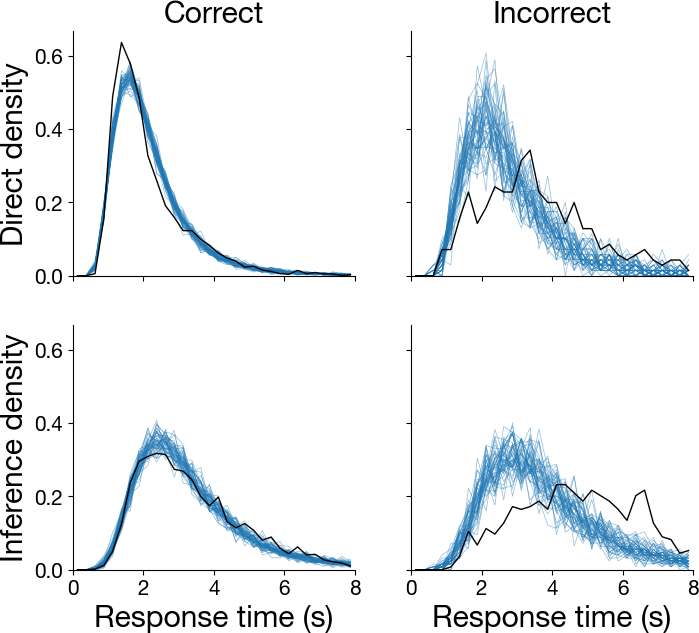

In [3]:
fig, ax = figures.plot_predictive(pp, group='posterior', max_time=max_time)
figures.savefig(fig, fig_dir / 'predictive_rt_dist.pdf')

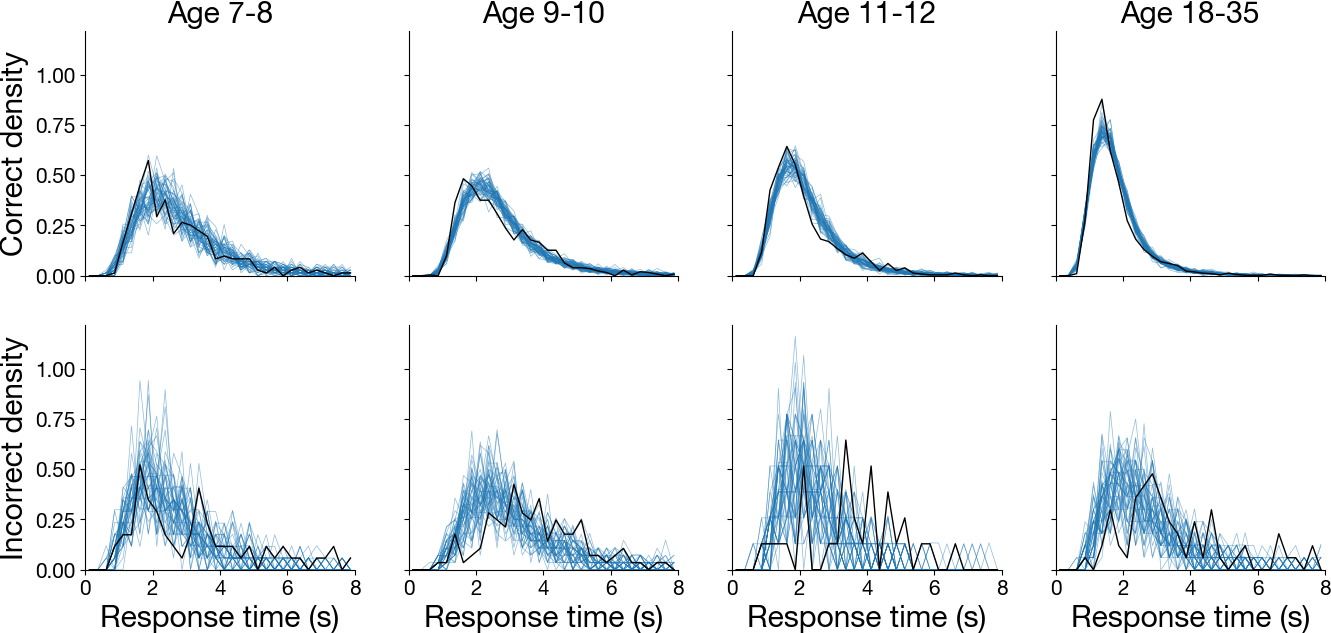

In [4]:
fig, ax = figures.plot_predictive(
    pp, 
    group='posterior', 
    max_time=max_time, 
    row='accuracy', 
    col='age', 
    trial_type='direct',
)
figures.savefig(fig, fig_dir / 'predictive_rt_dist_direct.pdf')

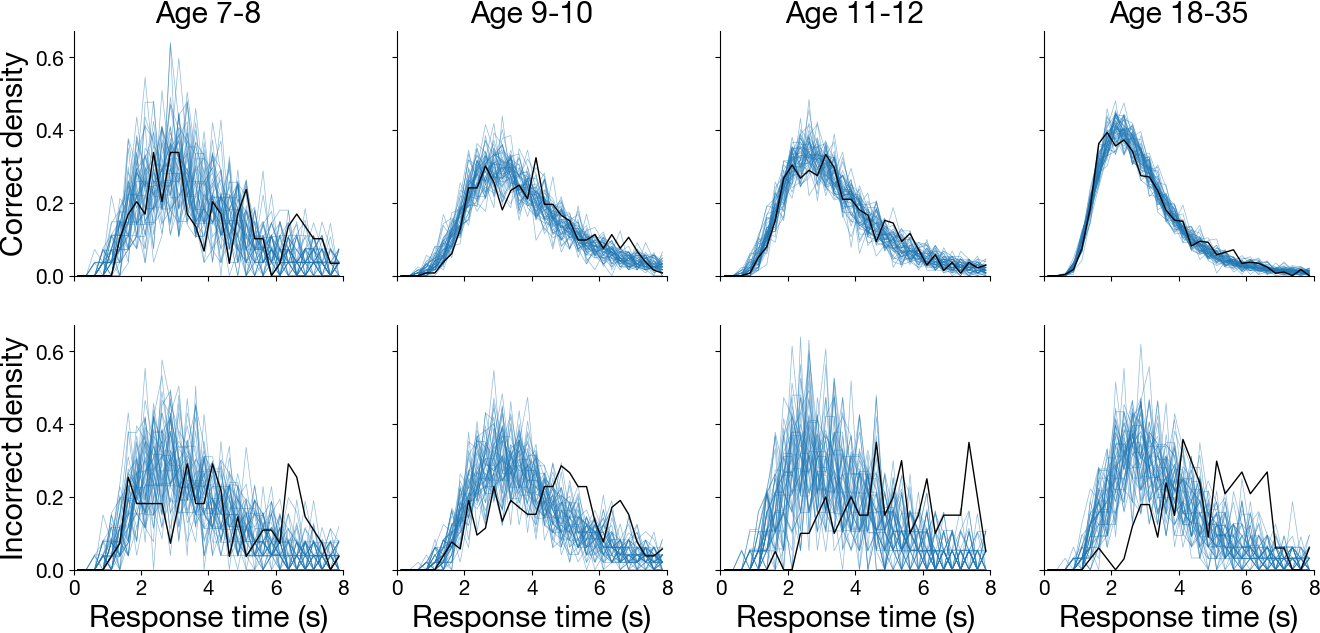

In [5]:
fig, ax = figures.plot_predictive(
    pp, 
    group='posterior', 
    max_time=max_time, 
    row='accuracy', 
    col='age', 
    trial_type='inference',
)
figures.savefig(fig, fig_dir / 'predictive_rt_dist_inference.pdf')

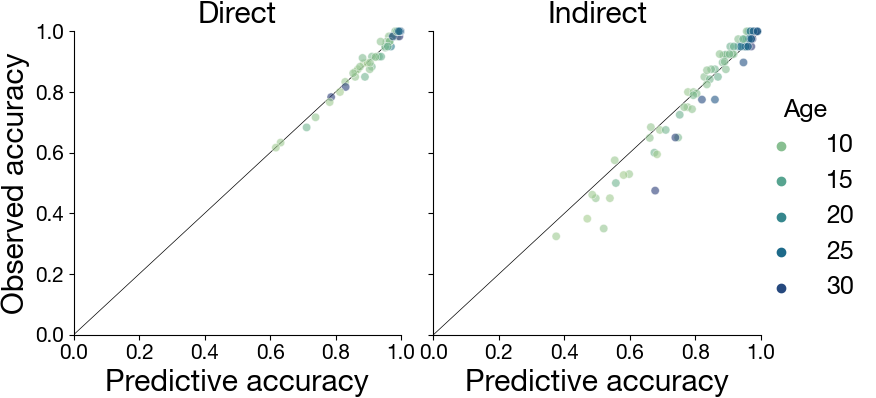

In [6]:
g = figures.plot_predictive_acc(pp)
figures.savefig(g, fig_dir / 'predictive_accuracy.pdf')

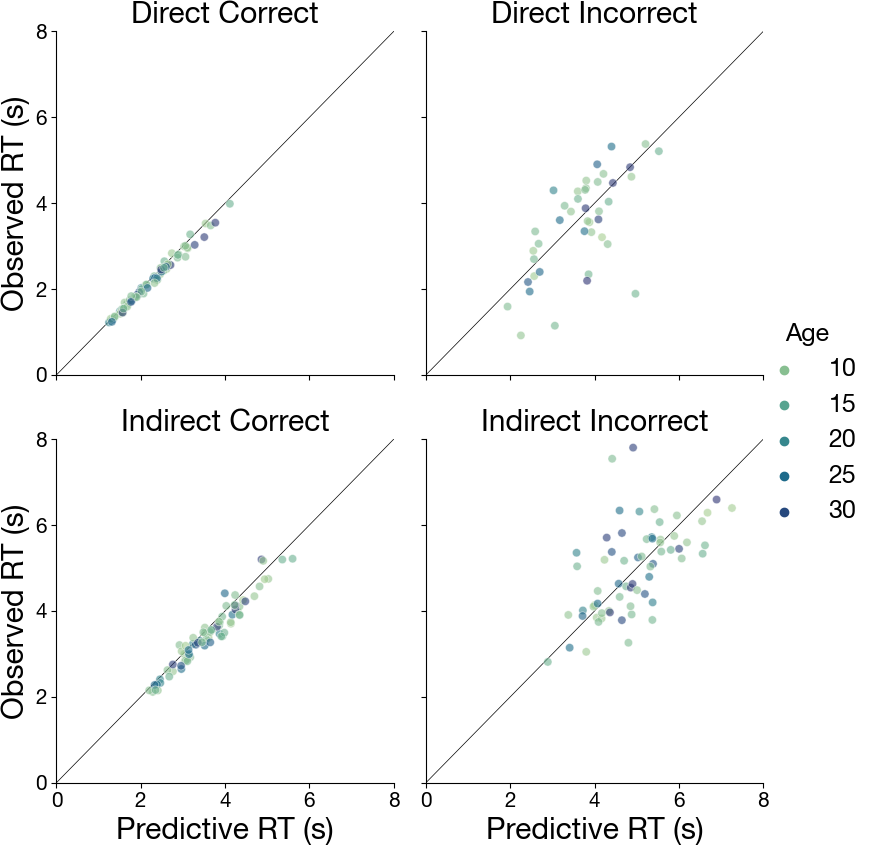

In [7]:
g = figures.plot_predictive_rt(pp, max_time=max_time)
figures.savefig(g, fig_dir / 'predictive_rt.pdf')

In [8]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.10.5
IPython version      : 8.5.0

seaborn   : 0.11.2
pandas    : 1.5.0
matplotlib: 3.6.0
arviz     : 0.12.1
devreact  : 0.1.0
numpy     : 1.21.6

